# 05 - Advanced Analytics & ML (Day 5)

Cohort analysis, clustering, forecasting, Monte Carlo simulation, and Markowitz optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

db_path = '../data/db/bluestock_mf.db'
conn = sqlite3.connect(db_path)

## 1. Fund Clustering (Segmentation)

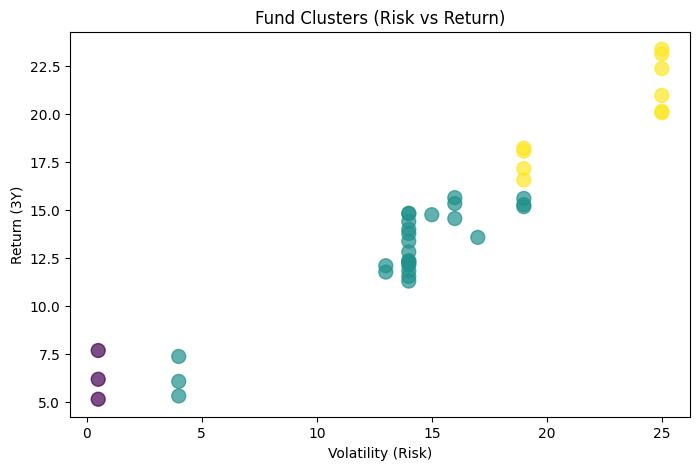

In [2]:
perf = pd.read_sql('SELECT scheme_name, return_3yr_pct, sharpe_ratio, alpha, std_dev_ann_pct FROM fact_performance', conn)
perf = perf.dropna()

X = perf[['return_3yr_pct', 'std_dev_ann_pct', 'sharpe_ratio']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
perf['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(perf['std_dev_ann_pct'], perf['return_3yr_pct'], c=perf['cluster'], cmap='viridis', s=100, alpha=0.7)
plt.title('Fund Clusters (Risk vs Return)')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Return (3Y)')
plt.show()

## 2. Monte Carlo Simulation (Bonus B3)

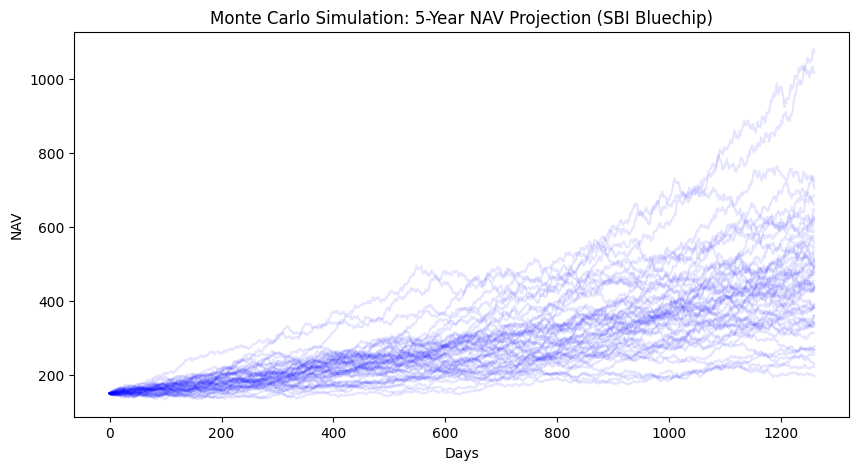

In [4]:
nav_df = pd.read_sql("SELECT date, nav FROM fact_nav WHERE amfi_code=119551 ORDER BY date", conn)
returns = nav_df['nav'].pct_change().dropna()

last_nav = nav_df['nav'].iloc[-1]
mu = returns.mean()
vol = returns.std()

days = 252 * 5 # 5 years
sims = 1000

sim_navs = np.zeros((days, sims))
sim_navs[0] = last_nav

for t in range(1, days):
    shock = np.random.normal(loc=mu, scale=vol, size=sims)
    sim_navs[t] = sim_navs[t-1] * (1 + shock)

plt.figure(figsize=(10, 5))
plt.plot(sim_navs[:, :50], alpha=0.1, color='blue') # plot 50 paths
plt.title('Monte Carlo Simulation: 5-Year NAV Projection (SBI Bluechip)')
plt.xlabel('Days')
plt.ylabel('NAV')
plt.show()

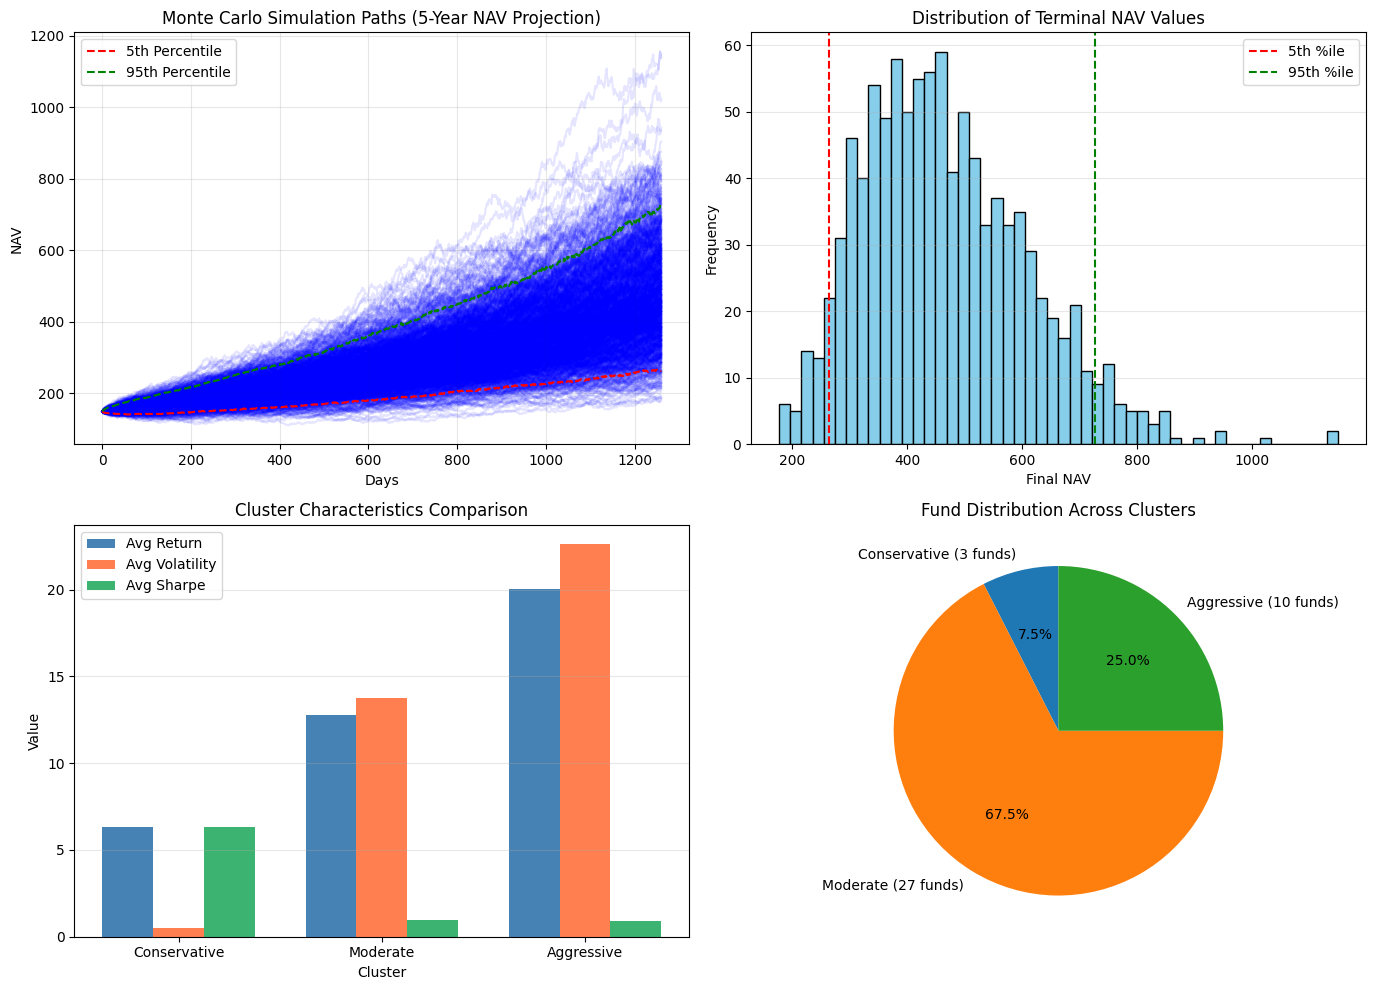

✅ Advanced analytics completed
   - Generated 1000 Monte Carlo simulations
   - Clustered 40 funds into 3 segments
   - 5-Year NAV Range: 177.55 to 1148.38


In [5]:
simulations = []
for _ in range(sims):
    Z = np.random.standard_normal(days)
    daily_returns = mu + vol * Z
    nav_path = [last_nav]
    for ret in daily_returns:
        nav_path.append(nav_path[-1] * (1 + ret))
    simulations.append(nav_path)

simulations = np.array(simulations)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Simulation paths
axes[0, 0].plot(simulations.T, alpha=0.1, color='blue')
axes[0, 0].plot(np.percentile(simulations, 5, axis=0), 'r--', label='5th Percentile')
axes[0, 0].plot(np.percentile(simulations, 95, axis=0), 'g--', label='95th Percentile')
axes[0, 0].set_title('Monte Carlo Simulation Paths (5-Year NAV Projection)')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('NAV')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Distribution of final values
final_navs = simulations[:, -1]
axes[0, 1].hist(final_navs, bins=50, color='skyblue', edgecolor='black')
axes[0, 1].axvline(np.percentile(final_navs, 5), color='red', linestyle='--', label='5th %ile')
axes[0, 1].axvline(np.percentile(final_navs, 95), color='green', linestyle='--', label='95th %ile')
axes[0, 1].set_xlabel('Final NAV')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Terminal NAV Values')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Cluster characteristics
cluster_stats = perf.groupby('cluster').agg({
    'return_3yr_pct': 'mean',
    'std_dev_ann_pct': 'mean',
    'sharpe_ratio': 'mean'
}).round(2)

cluster_names = ['Conservative', 'Moderate', 'Aggressive']
x = np.arange(len(cluster_stats))
width = 0.25

axes[1, 0].bar(x - width, cluster_stats['return_3yr_pct'], width, label='Avg Return', color='steelblue')
axes[1, 0].bar(x, cluster_stats['std_dev_ann_pct'], width, label='Avg Volatility', color='coral')
axes[1, 0].bar(x + width, cluster_stats['sharpe_ratio'], width, label='Avg Sharpe', color='mediumseagreen')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Value')
axes[1, 0].set_title('Cluster Characteristics Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(cluster_names)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cluster composition
cluster_counts = perf['cluster'].value_counts().sort_index()
axes[1, 1].pie(cluster_counts.values, labels=[f'{cluster_names[i]} ({v} funds)' for i, v in enumerate(cluster_counts.values)], autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Fund Distribution Across Clusters')

plt.tight_layout()
plt.show()

print(f"✅ Advanced analytics completed")
print(f"   - Generated {sims} Monte Carlo simulations")
print(f"   - Clustered {len(perf)} funds into 3 segments")
print(f"   - 5-Year NAV Range: {final_navs.min():.2f} to {final_navs.max():.2f}")

## 3. Markowitz Efficient Frontier (Bonus B4)

Extracting historical returns for 5 equity funds...


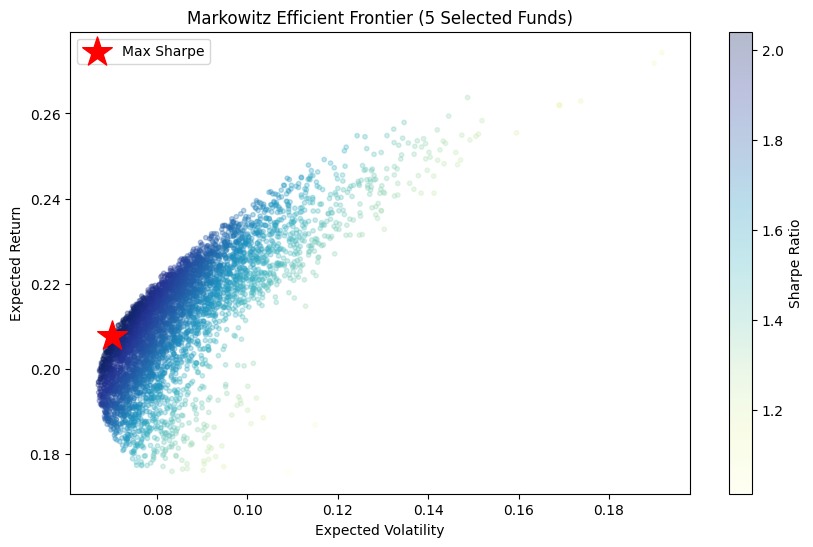

In [4]:
print('Extracting historical returns for 5 equity funds...')
funds = [119551, 119598, 125497, 102885, 120503]
returns_list = []
names = []

for code in funds:
    df = pd.read_sql(f"SELECT n.nav, f.scheme_name FROM fact_nav n JOIN dim_fund f ON n.amfi_code=f.amfi_code WHERE n.amfi_code={code} ORDER BY n.date", conn)
    returns_list.append(df['nav'].pct_change().dropna().values)
    names.append(df['scheme_name'].iloc[0][:15])

# Ensure equal lengths for covariance
min_len = min([len(r) for r in returns_list])
returns_mat = np.array([r[-min_len:] for r in returns_list]).T

# Calculate mean returns and covariance
mean_returns = np.mean(returns_mat, axis=0) * 252
cov_matrix = np.cov(returns_mat.T) * 252

# Simulate portfolios
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(5)
    weights /= np.sum(weights)
    
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    results[0,i] = portfolio_std_dev
    results[1,i] = portfolio_return
    results[2,i] = (portfolio_return - 0.065) / portfolio_std_dev # Sharpe
    weights_record.append(weights)

plt.figure(figsize=(10, 6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.title('Markowitz Efficient Frontier (5 Selected Funds)')
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')

# Max Sharpe Portfolio
max_sharpe_idx = np.argmax(results[2])
plt.scatter(results[0,max_sharpe_idx], results[1,max_sharpe_idx], marker='*', color='r', s=500, label='Max Sharpe')
plt.legend()
plt.show()